# Box Plots

DS 2023 | Communicating with Data

## Overview

:::{image}images/box_plot.png
:width: 500px
:align: left
:::

A box plot is a way to display the summary statistics of a numeric feature.

It uses a minimalist geometric drawing composed of a set of glyphs &mdash; a rectangle (the "box"), perpendicular lines (the "whiskers"), and small circles &mdash; plotted along a line. 

The line is metric, such that distance maps onto a numeric scale, and the position of the glyphps along the axis signifies their numeric values.

Because of its design, box plots are often called "box-and-whiskers" plots.

Using the symbolism of the image, a box plot represents the following statistics:

- Minimum value: far left whisker
- First quartile (Q1): far left box border
- Median value: central line
- Third quartile (Q3): far right box border
- Maximum value: far right whishker
- Interquartile range (IQR): the box
- Outliers: dots to the left and right of Q1 and Q3

It was invented by [Mary Eleanor Spear](https://en.wikipedia.org/wiki/Mary_Eleanor_Spear) and later developed by John Tukey.

## Use Cases

It is a highly effective tool for visualizing data spread, skewness, and identifying outliers.

Outlier detection

Visual model of summary statistics

## How box plots are constructed

Explain how the values are computed.

See https://www.geeksforgeeks.org/data-analysis/box-plot/ and https://www.atlassian.com/data/charts/box-plot-complete-guide

## Examples

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
healthexp = sns.load_dataset('healthexp')
healthexp.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


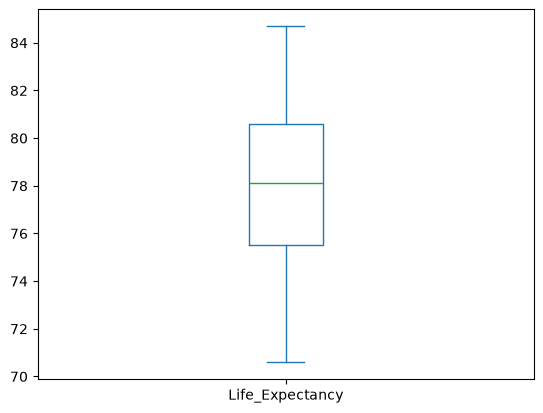

In [4]:
healthexp.Life_Expectancy.plot.box()
plt.show()

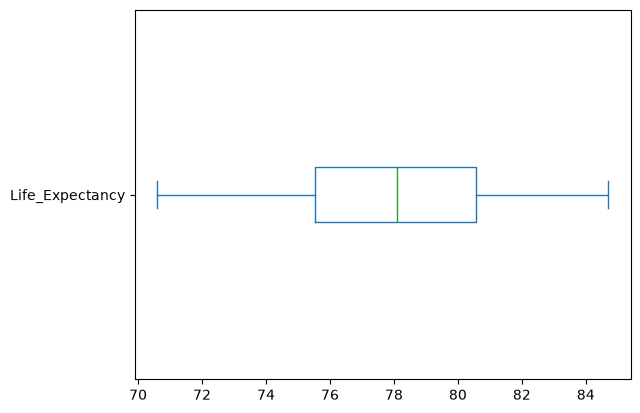

In [5]:
healthexp.Life_Expectancy.plot.box(vert=False)
plt.show()

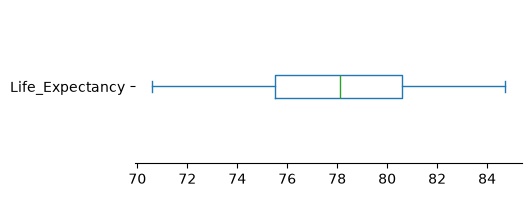

In [6]:
healthexp.Life_Expectancy.plot.box(vert=False, figsize=(5, 2))
sns.despine(left=True)
plt.show()

## Showing box plots by category

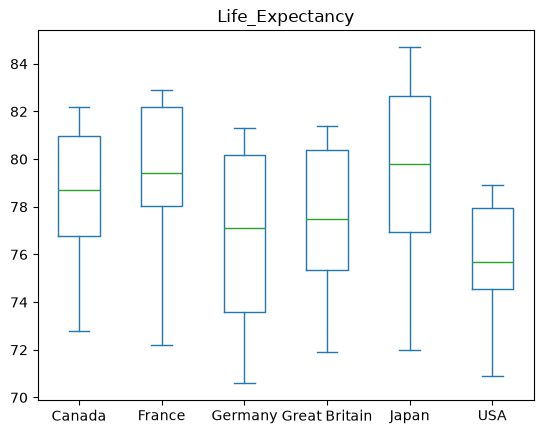

In [20]:
healthexp.plot.box(column="Life_Expectancy", by="Country")
plt.show()

In [7]:
life_exp_wide = healthexp.pivot(index='Year', columns='Country', values='Life_Expectancy')
life_exp_wide.head()

Country,Canada,France,Germany,Great Britain,Japan,USA
Year,,,,,,
1970,NaN,72.2,70.6,71.9,72.0,70.9
1971,72.8,NaN,70.8,71.9,72.9,71.2
1972,NaN,NaN,71.0,NaN,73.2,71.2
1973,NaN,NaN,71.3,NaN,73.4,71.4
1974,NaN,NaN,71.5,NaN,73.7,72.0


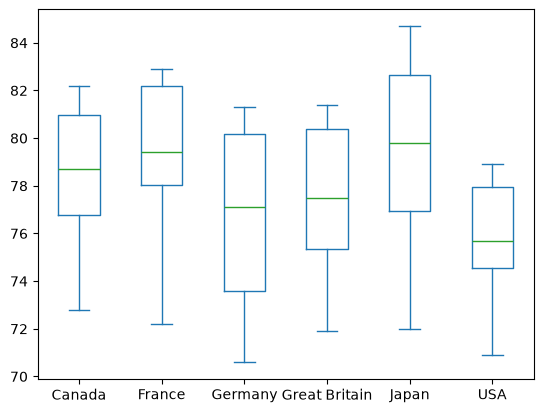

In [8]:
life_exp_wide.plot.box()
plt.show()

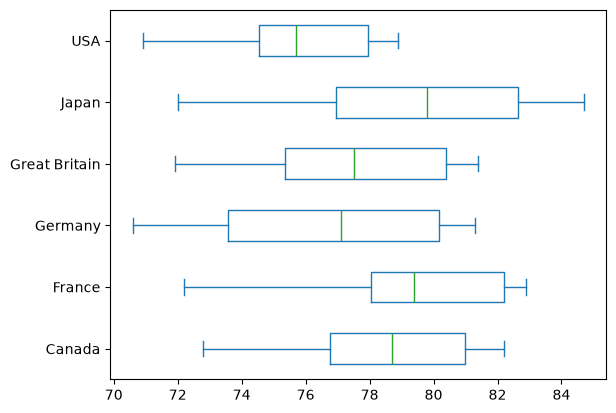

In [9]:
life_exp_wide.plot.box(vert=False)
plt.show()

We can use subplots, but since box plots are relatively compact, there is no real value gained by doing this.

In fact, it complicates things.

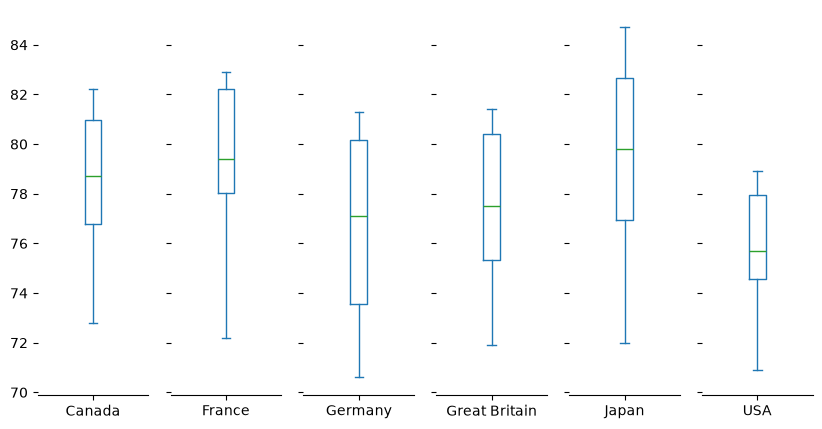

In [10]:
life_exp_wide.plot.box(subplots=True, figsize=(10,5), sharey=True)
sns.despine(left=True)
plt.show()

## Combining box plots and histograms

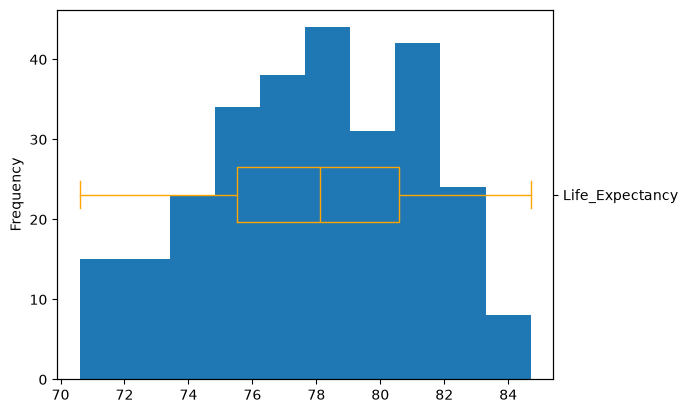

In [11]:
healthexp.Life_Expectancy.plot.hist()
plt.gca().twinx()
healthexp.Life_Expectancy.plot.box(vert=False, color='orange')
plt.show()

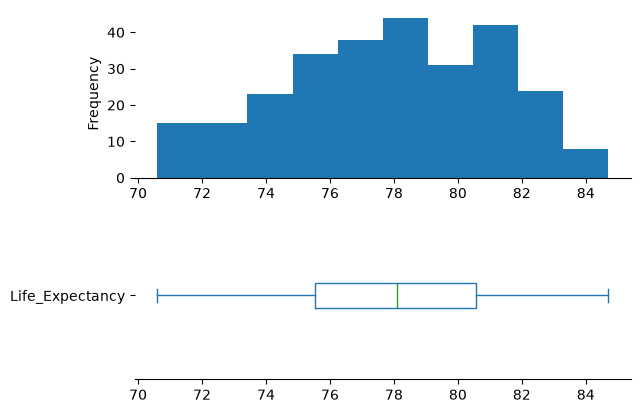

In [12]:
fig, ax = plt.subplots(2, 1)
healthexp.Life_Expectancy.plot.hist(ax=ax[0])
healthexp.Life_Expectancy.plot.box(ax=ax[1], vert=False)
sns.despine(left=True)
plt.show()

## Showing outliers

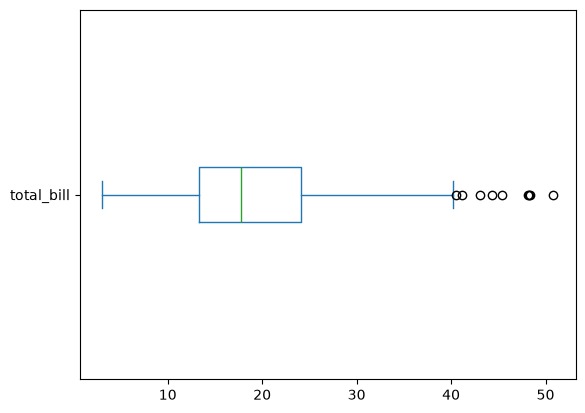

In [41]:
tips.total_bill.plot.box(vert=False)
plt.show()

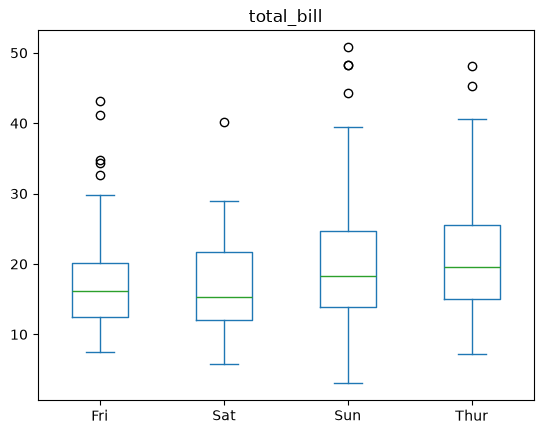

In [25]:
tips.plot.box(column='total_bill', by='day')
plt.show()

Note the order of the days.

In [84]:
tip_groups = tips.groupby('day')
tips_wide = pd.concat([g[1].total_bill for g in tip_groups], axis=1, keys=[g[0] for g in tip_groups])
tips_wide.sort_index()

,Thur,Fri,Sat,Sun
0,NaN,NaN,NaN,16.99
1,NaN,NaN,NaN,10.34
2,NaN,NaN,NaN,21.01
3,NaN,NaN,NaN,23.68
4,NaN,NaN,NaN,24.59
...,...,...,...,...
239,NaN,NaN,29.03,NaN
240,NaN,NaN,27.18,NaN
241,NaN,NaN,22.67,NaN
242,NaN,NaN,17.82,NaN


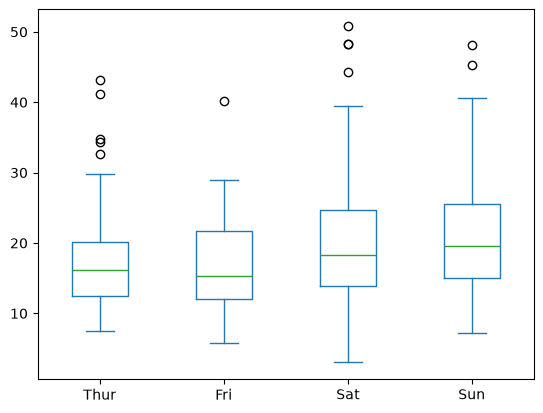

In [85]:
tips_wide.plot.box()
plt.show()

## Using Seaborn

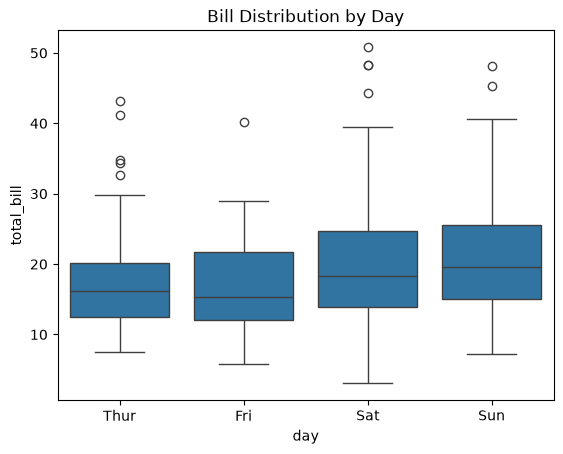

In [24]:
sns.boxplot(x="day", y="total_bill", data=tips)
plt.title("Bill Distribution by Day")
plt.show()